<a href="https://colab.research.google.com/github/TommasoFalossi/Brownian_Motion/blob/main/Random_Walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as rn

#Einstein Model of Brownian Motion

In [ ]:
def EinBrownMot(x_0, t_0, t_f, mu=0, sigma=1, N=1000):
  T=np.linspace(t_0, t_f, N)
  X=[]

  jumps = rn.gauss(mu, sigma)
  for t in T:
    if(t == 0):
      X.append(x_0)

    else:
      jump = rn.gauss(mu, sigma)
      X.append(X[-1] + jump)

  return X

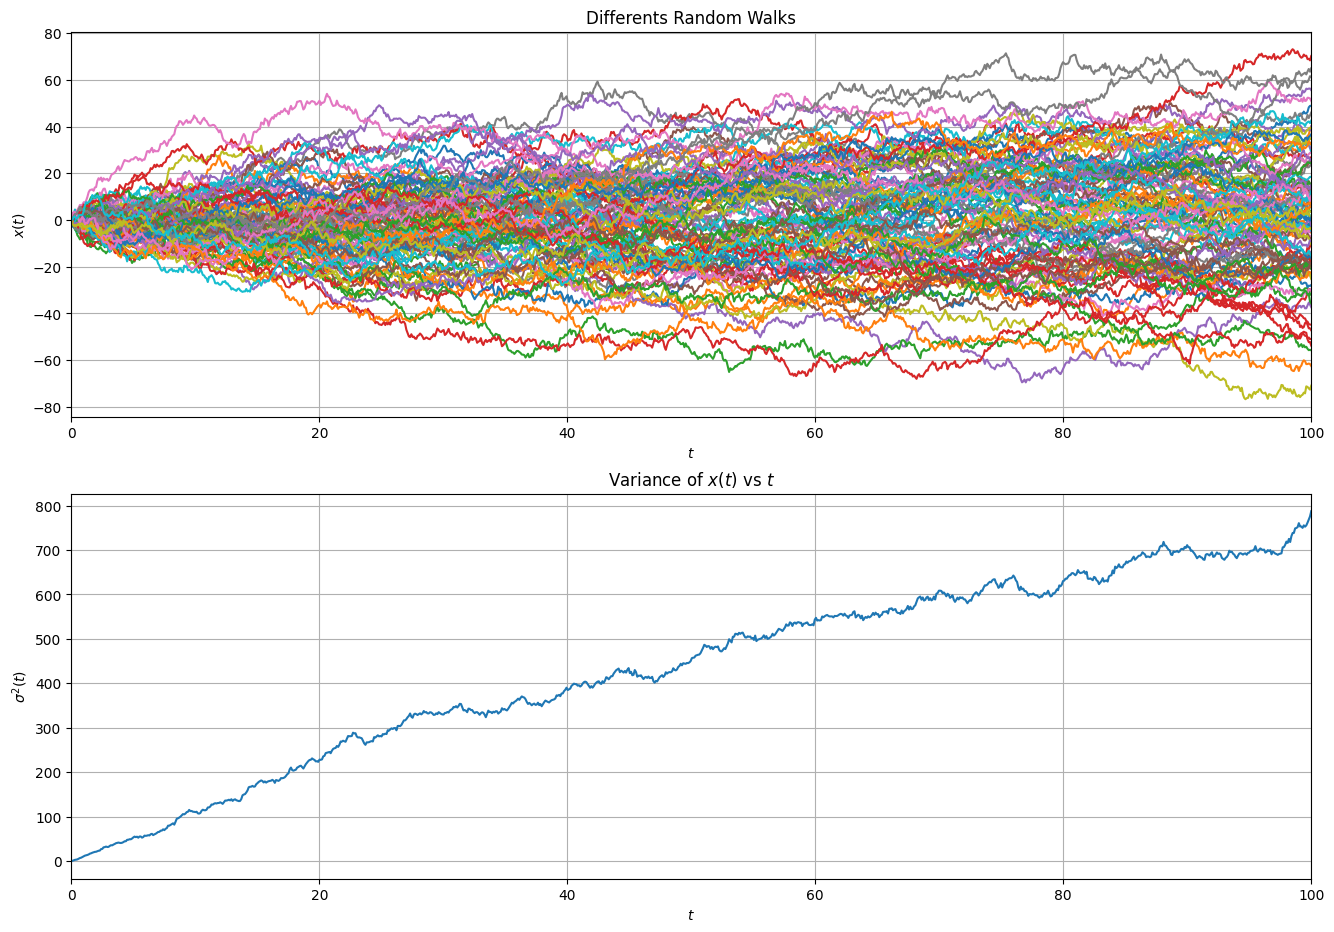

In [ ]:
plt.figure(figsize=(16, 11))

plt.subplot(211)
t0 = 0
tf = 100
N = 1000

X = []
T= np.linspace(t0, tf, n)

for a in range(100):

  X.append(EinBrownMot(0, t0, tf, N=N))

  plt.plot(T, X[a])

plt.grid()
plt.xlabel(r"$t$")
plt.ylabel(r"$x (t)$")
plt.title("Differents Brownian Motions")
plt.xlim(t0, tf)

plt.subplot(212)
plt.title(r"Variance of $x(t)$ vs $t$")

Var = []
X_arr = np.array(X)

for t in range(n):
  xt = X_arr[:, t]
  vart = xt.var()
  Var.append(vart)


plt.xlabel(r"$t$")
plt.ylabel(r"$\sigma^2 (t)$")
plt.plot(T, Var)
plt.xlim(t0, tf)
plt.grid()

plt.show()

##Gif

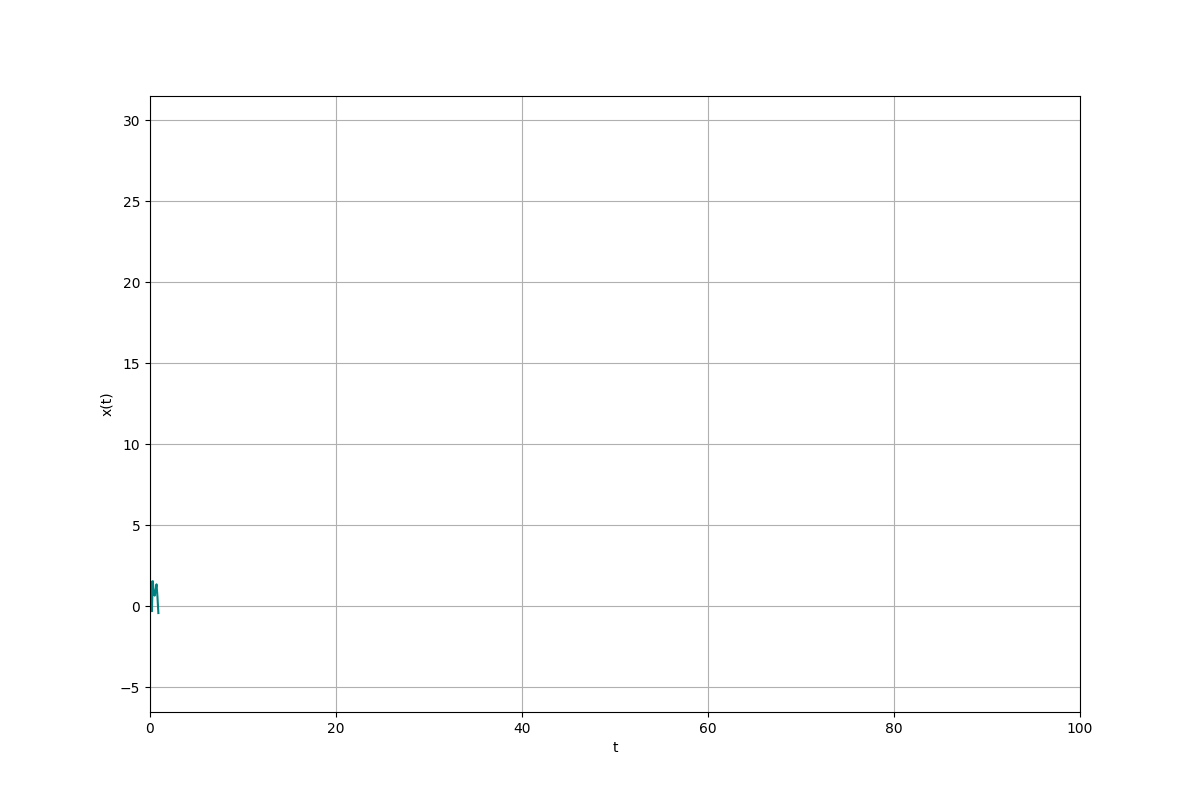

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image

Num_frame=100

x0 = 0
t0 = 0
tf = 100
X = EinBrownMot(x0, t0, tf)

step = int(N/Num_frame)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.clear()
ax.grid()
ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_xlim(t0, tf)
ax.set_ylim(np.array(X).min()*1.1, np.array(X).max()*1.1)

line, = ax.plot([], [], color='teal')

def update(frame_index):
  line.set_data(T[:(frame_index+1)*step], X[:(frame_index+1)*step])

  return line,



FuncAnimation(fig, update, Num_frame, blit=True).save('BrownMotion.gif', writer='pillow')

plt.close()


Image('BrownMotion.gif')

#Random Walk

##Bachelier Random Walks

In [ ]:
def binRandomWalk( x_0 : int, p : float, N : int) -> list[int]:
  pos = x_0
  POS = [pos]
  for i in range(N):
    a = rn.random()
    if(a <= p):
      pos+=1
    else:
      pos-=1
    POS.append(pos)

  return POS



def RandomWalkSim( x_0 : int, p : float, N : int, n : int) -> np.ndarray:

  Positions =np.zeros((n, N+1))


  for i in range(n):

    Positions[i, :] = np.array(binRandomWalk(x_0, p, N))

  return Positions #Return a matrix where each row is a different random walk simulation

In [ ]:
def RandomWalkSim2( x_0 : int, p : float, N : int, n : int) -> np.ndarray:

    probs = np.random.rand(n, N)

    salti = np.where(probs <= p, 1, -1)

    Trajectories = np.cumsum(salti, axis=1) + x_0

    X_0 = np.full((n, 1), x_0)
    Positions = np.column_stack((X_0, Trajectories))

    return Positions

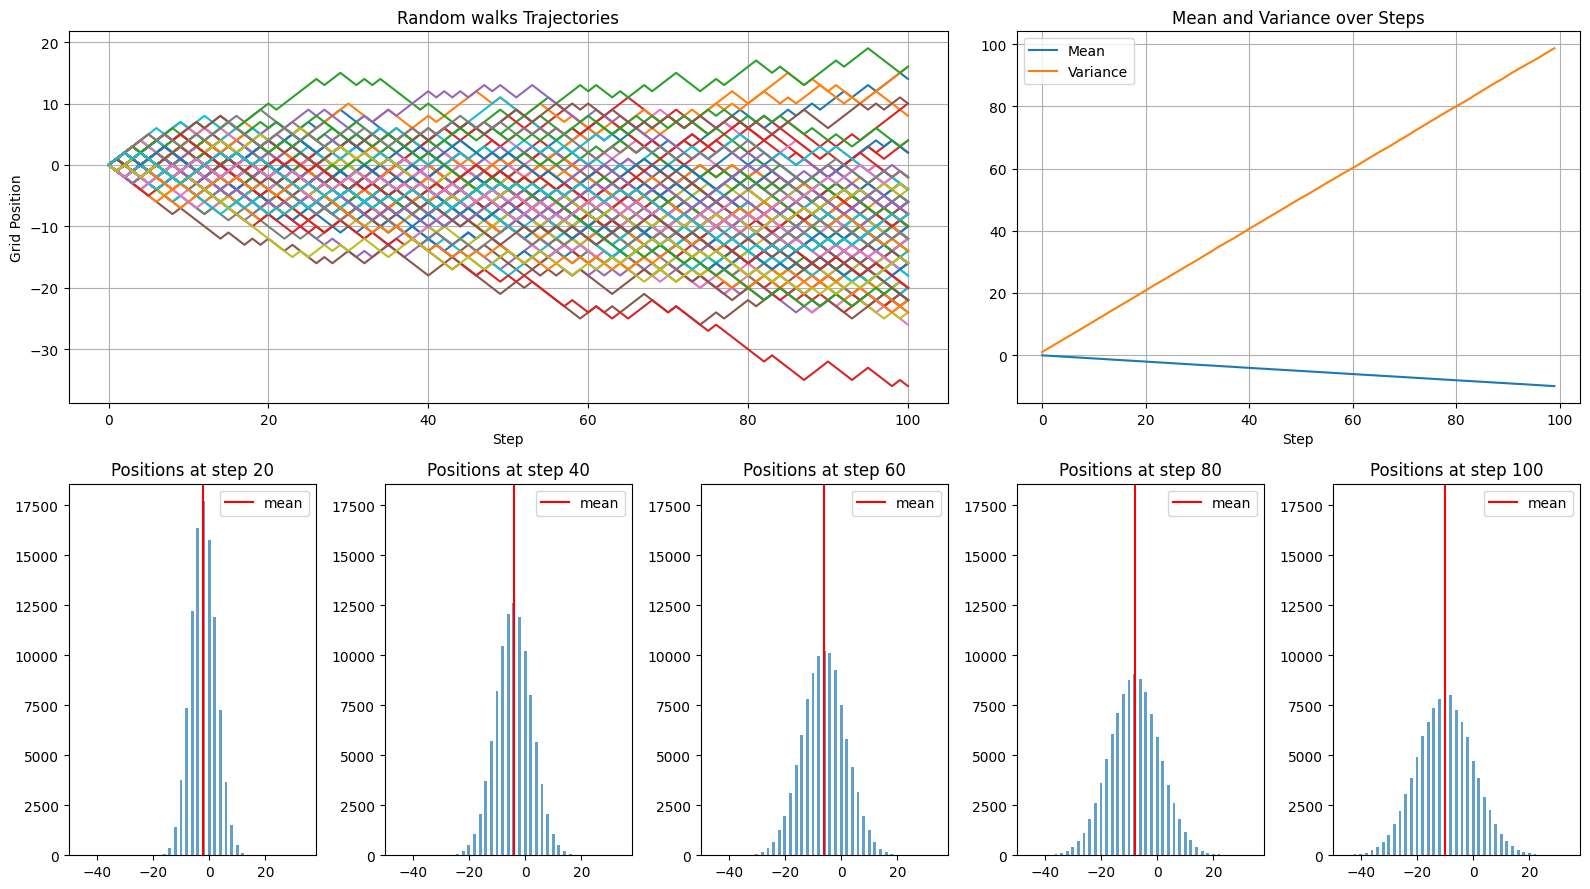

In [ ]:
x_0 = 0
N = 100 #Number of steps

h = int(N/5)
indices=[]
for i in range(int(N/h)):
 indices.append(h*(i+1))
p = 0.45

n = 100000 #Number of simulation

plt.figure(figsize= (16, 9))
plt.subplot(2, 5, (1, 3))
plt.title("Random walks Trajectories")
plt.grid()
plt.xlabel('Step')
plt.ylabel('Grid Position')

Histo = np.zeros((n, 5))

Pos = RandomWalkSim2(x_0, p, N, n)



if(n > 100):
  for i in range(100):
    plt.plot(range(N+1), Pos[i, :])

else:
  for i in range(n):
    plt.plot(range(N+1), Pos[i, :])




Mu = np.mean(Pos[:, 1:], axis=0)
Var = np.var(Pos[:, 1:], axis=0)



plt.subplot(2, 5, (4,5))
plt.grid()
plt.xlabel('Step')
plt.title("Mean and Variance over Steps")
plt.plot(range(N), Mu, label='Mean')
plt.plot(range(N), Var, label='Variance')
plt.legend()

for k, j in enumerate(indices):
    Histo[:, k] = Pos[:, j]

xmax = Histo.max()
xmin = Histo.min()

bin_edges = np.arange(xmin - 0.5, xmax + 1.5, 1)

ax_ref=None

for i in range(5):
  ax = plt.subplot(2, 5, 6 + i, sharey=ax_ref)

  if(ax_ref==None):
    ax_ref=ax

  plt.title(f"Positions at step {(i+1)*h}")
  plt.hist(Histo[:, i], bins = bin_edges, alpha=0.7)
  plt.axvline(Histo[:, i].mean(), color="red", label="mean")
  plt.legend()
  plt.xlim(xmin, xmax)

ax_ref.margins(y=0.05)

plt.tight_layout()
plt.show()

##Limit of Continuum

In [ ]:
def RandomWalkSimCont( x_0 : int, p : float, Delta_X:float,  N : int, n : int) -> np.ndarray:

    probs = np.random.rand(n, N)

    salti = np.where(probs <= p, 1, -1)

    Trajectories = np.cumsum(salti, axis=1) + x_0

    X_0 = np.full((n, 1), x_0)
    Positions = np.column_stack((X_0, Trajectories))

    return Positions*Delta_X

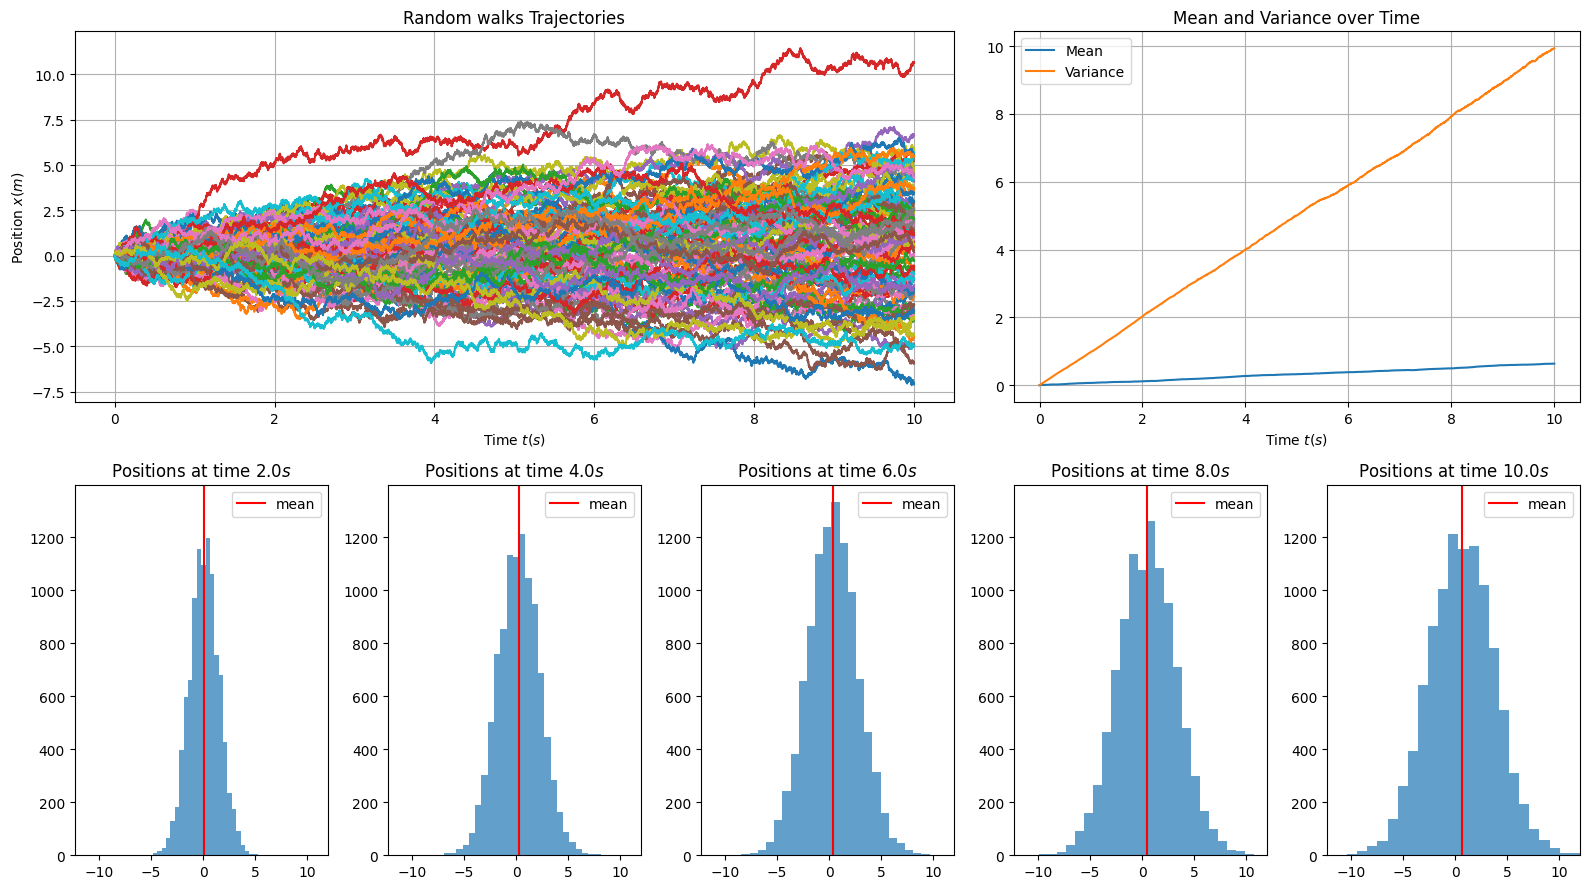

In [ ]:
x_0 = 0

N = 10000 #Number of steps


Delta_t = 0.001
Delta_X = np.sqrt(Delta_t)

T = Delta_t * N

Times=np.linspace(0, T, N+1)



h = int(N/5)
indices=[]
for i in range(int(N/h)):
 indices.append(h*(i+1))
p = 0.501

n = 10000 #Number of simulation

plt.figure(figsize= (16, 9))
plt.subplot(2, 5, (1, 3))
plt.title("Random walks Trajectories")
plt.grid()
plt.xlabel(r'Time $t(s)$')
plt.ylabel(r'Position $x(m)$')

Histo = np.zeros((n, 5))

Pos = RandomWalkSimCont(x_0, p, Delta_X,  N, n)



if(n > 100):
  for i in range(100):
    plt.plot(Times, Pos[i, :])

else:
  for i in range(n):
    plt.plot(Times, Pos[i, :])




Mu = np.mean(Pos[:, 1:], axis=0)
Var = np.var(Pos[:, 1:], axis=0)



plt.subplot(2, 5, (4,5))
plt.grid()
plt.xlabel(r'Time $t(s)$')
plt.title("Mean and Variance over Time")
plt.plot(Times[1:], Mu, label='Mean')
plt.plot(Times[1:], Var, label='Variance')
plt.legend()


for k, j in enumerate(indices):
    Histo[:, k] = Pos[:, j]

xmax = Histo.max()
xmin = Histo.min()

bin_edges = np.arange(xmin - 0.5, xmax + 1.5, 1)

ax_ref=None

for i in range(5):
  ax = plt.subplot(2, 5, 6 + i, sharey=ax_ref)

  if(ax_ref==None):
    ax_ref=ax

  plt.title(rf"Positions at time ${Times[int((i+1)*h)]} s$")
  plt.hist(Histo[:, i], bins = 25,  alpha=0.7)
  plt.axvline(Histo[:, i].mean(), color="red", label="mean")
  plt.legend()
  plt.xlim(xmin, xmax)

ax_ref.margins(y=0.05)

plt.tight_layout()
plt.show()